# Actividad 4

**Name**: William Frank Monroy Mamani

**ID**: A00829796

**Link to GitHub**: https://github.com/william-monroy/mem-estadistics/blob/master/notebooks/actividades/actividad_4/Actividad_4.ipynb


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay 

# Variables globales
sns.set_theme(style="whitegrid")
RANDOM_STATE = 301655
FEATURES = [
    "Air_temperature",
    "Process_temperature",
    "Rotational_speed",
    "Torque",
    "Tool_wear",
]


# Problem

A manufacturing engineer is trying to predict whether a machine will experience a failure during operation. To this end, the engineer collected several sensor measurements that describe the operating conditions of the machine:

- `Air_temperature`. Temperature of the surrounding environment (K).

- `Process_temperature`. Temperature of the manufacturing process (K).

- `Rotational_speed`. Speed of the machine spindle (RPM).

- `Torque`. Mechanical torque applied during operation (Nm).

- `Tool_wear`. Amount of wear accumulated by the cutting tool (minutes).

The response under study is `Machine_failure` and has two classes: “Yes and “No.” They denote whether the machine experienced a failure under the observed operating conditions.

The dataset for this exercise is available in the "Maintenance.xlsx" file on CANVAS.


## Question 0

Read data into Python using pandas

In [2]:
data = pd.read_excel("data/Maintenance.xlsx")
data["Machine_failure"] = pd.Categorical(
    data["Machine_failure"], categories=["No", "Yes"]
)

data.head()


,UDI,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Machine_failure
0,1,298.1,308.6,1551,42.8,0,No
1,2,298.2,308.7,1408,46.3,3,No
2,3,298.1,308.5,1498,49.4,5,No
3,4,298.2,308.6,1433,39.5,7,No
4,5,298.2,308.7,1408,40.0,9,No


## Question 1

A) Compute the average value of each of the five predictors by the categories of `Machine_failure`. *Hint*: Use the function `.group_by()` from pandas.

In [3]:
group_means = data.groupby("Machine_failure", observed=False)[FEATURES].mean().round(2)
group_means


,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear
Machine_failure,,,,,
No,298.41,308.58,1540.98,39.18,104.32
Yes,300.89,310.29,1496.49,50.17,143.78


B) Explore the data graphically in order to investigate the association between `Machine_failure` and each of the other predictors. Include at least three plots with interpretation. *Hint*: For each predictor, construct one boxplot for the predictor values under each level of the response.

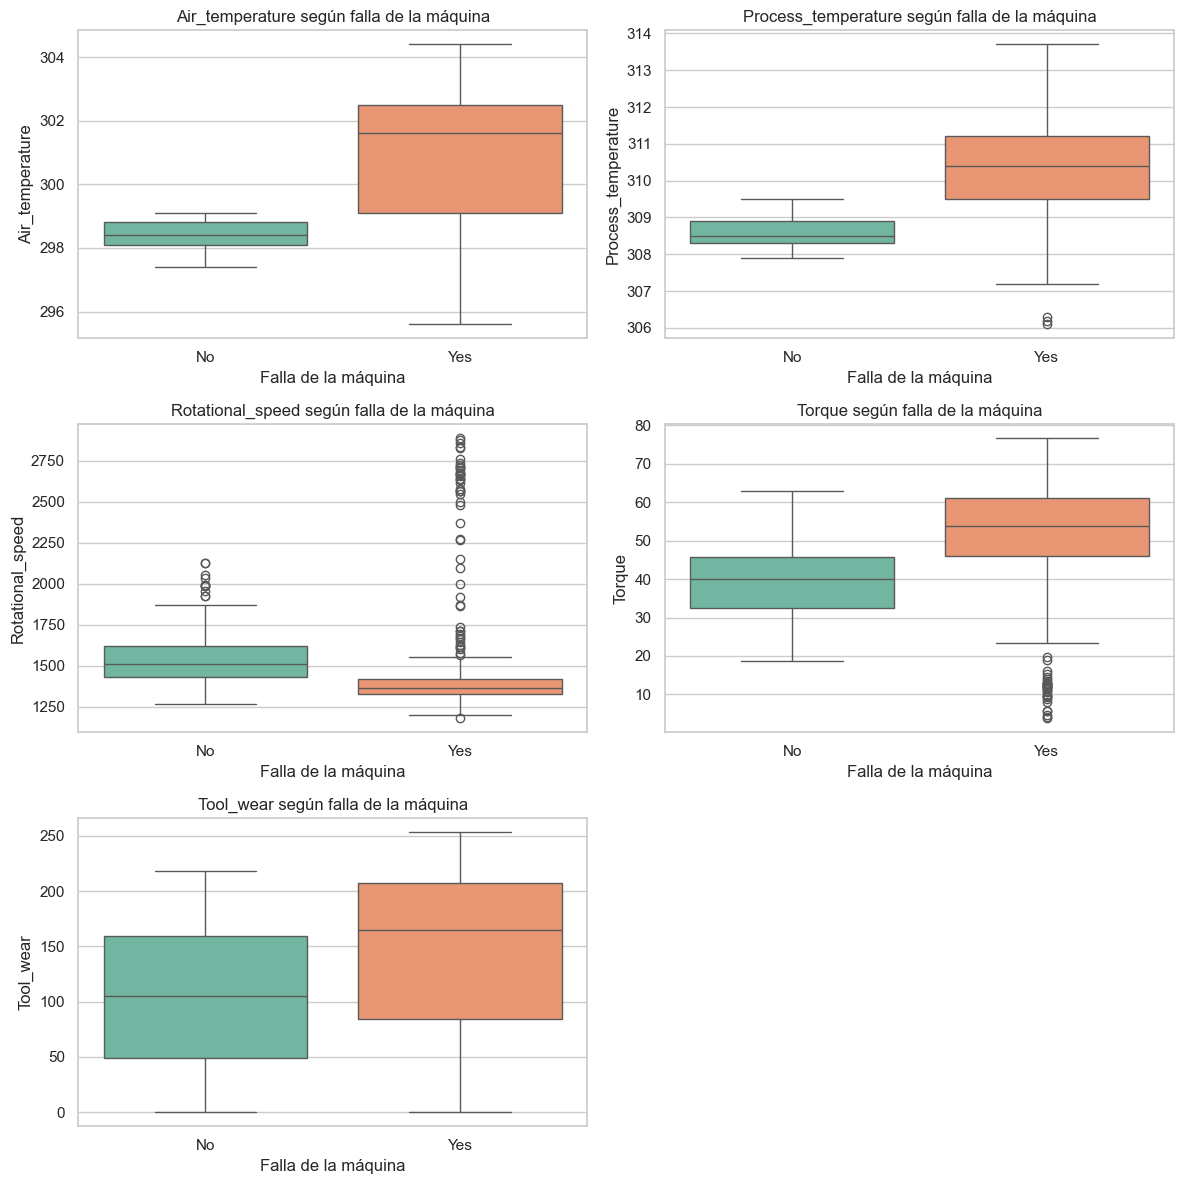

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, column in zip(axes, FEATURES):
    sns.boxplot(
        data=data,
        x="Machine_failure",
        y=column,
        hue="Machine_failure",
        ax=ax,
        palette="Set2",
    )
    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.set_title(f"{column} según falla de la máquina")
    ax.set_xlabel("Falla de la máquina")
    ax.set_ylabel(column)

# Ocultamos el espacio vacío.
axes[-1].axis("off")
plt.tight_layout()
plt.show()

C) Which predictors seem more likely to be useful in predicting `Machine_failure`? Justify your answer.

Respuesta

Los predictores que parecen más útiles son `Air_temperature` y `Process_temperature`, porque en ambos boxplots la separación entre clases es bastante clara. `Torque` también aporta una señal visible, ya que en las máquinas con falla suele tomar valores más altos. `Rotational_speed` y `Tool_wear` también ayudan, pero con más cuidado al interpretarlos: la velocidad de rotación tiene muchos valores atípicos, aunque su mediana sí cambia entre grupos, y el desgaste de herramienta presenta más traslape entre las dos clases.


## Question 2

A) Set the target category to `Yes`.

In [5]:
Y_dummies = pd.get_dummies(data["Machine_failure"], dtype="int")
Y_target_full = Y_dummies["Yes"]

Y_target_full.head()


0    0
1    0
2    0
3    0
4    0
Name: Yes, dtype: int64

B) Split the data into training and validation. Use 80% for training and 20% for testing.

In [6]:
X_full = data[FEATURES]

# Divimos los datos en entrenamiento y prueba.
X_train, X_test, Y_train, Y_test = train_test_split(
    X_full,
    Y_target_full,
    stratify=Y_target_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")


Tamaño de entrenamiento: (532, 5)
Tamaño de prueba: (133, 5)


## Question 3

A) Train a K-nearest neighbors algorithm on the training data in order to predict `Machine_failure` using all predictors. Identify the best value of *K* using cross-validation.

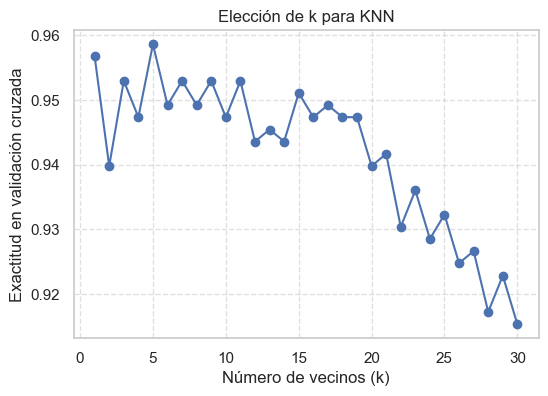

Mejor k: 5


In [7]:
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test = scaler.transform(X_test)

param_grid_knn = {"n_neighbors": range(1, 31)}
grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="accuracy",
)
grid_search_knn.fit(Xs_train, Y_train)

k_values = list(param_grid_knn["n_neighbors"])
validation_accuracies = grid_search_knn.cv_results_["mean_test_score"]
best_k = grid_search_knn.best_params_["n_neighbors"]

plt.figure(figsize=(6, 4))
plt.plot(k_values, validation_accuracies, marker="o")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Exactitud en validación cruzada")
plt.title("Elección de k para KNN")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

print(f"Mejor k: {best_k}")


B) Compute the accuracy of the KNN algorithm on the test dataset.

Exactitud de KNN en prueba: 0.9624


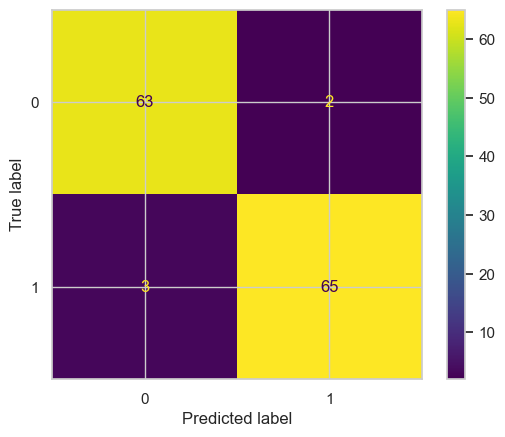

In [8]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(Xs_train, Y_train)

Y_pred_knn = knn_final.predict(Xs_test)
knn_accuracy = accuracy_score(Y_test, Y_pred_knn)

print(f"Exactitud de KNN en prueba: {knn_accuracy:.4f}")

cm = confusion_matrix(Y_test, Y_pred_knn)
ConfusionMatrixDisplay(cm).plot()


## Question 4

A) Train a classification tree on the training data in order to predict `Machine_failure` using all predictors.

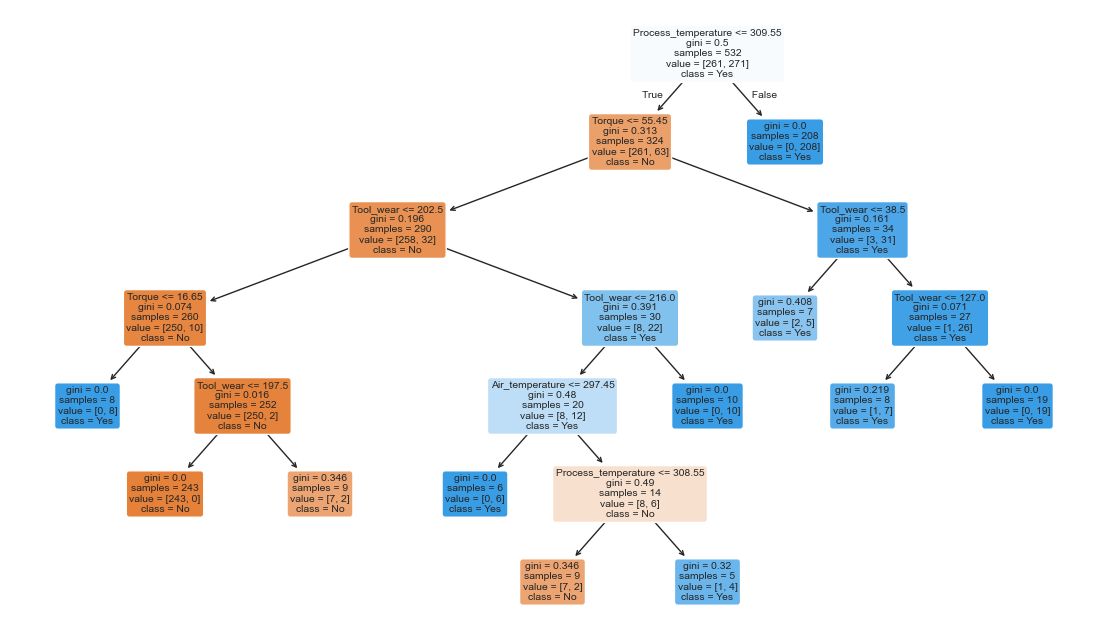

In [9]:
tree_model = DecisionTreeClassifier(
    min_samples_leaf=5,
    ccp_alpha=0,
    random_state=RANDOM_STATE,
)
tree_model.fit(X_train, Y_train)

plt.figure(figsize=(14, 8))
plot_tree(
    tree_model,
    feature_names=X_train.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
)
plt.show()


B) Use cost complexity pruning to build an alternative classification tree that predicts `Machine_failure`. Identify the best value of cost complexity pruning using cross-validation.

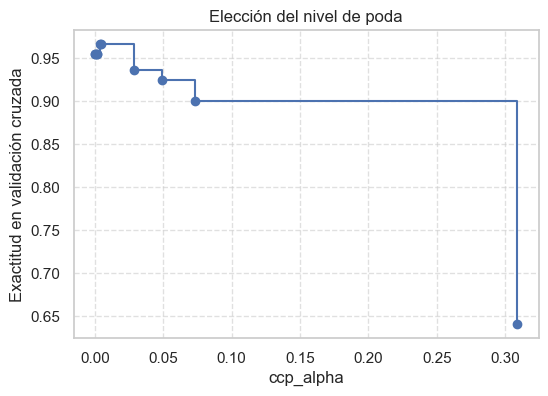

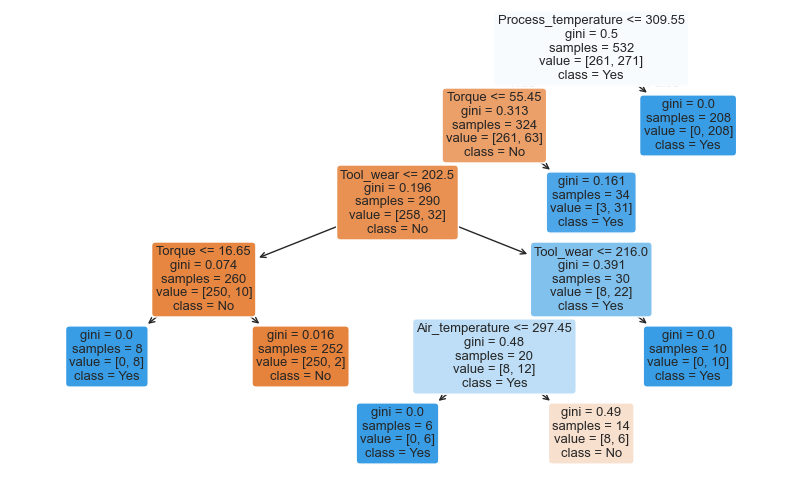

Mejor ccp_alpha: 0.004034


In [10]:
pruning_path = tree_model.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = pruning_path.ccp_alphas

param_grid_tree = {"ccp_alpha": ccp_alphas}
grid_search_tree = GridSearchCV(
    DecisionTreeClassifier(min_samples_leaf=5, random_state=RANDOM_STATE),
    param_grid_tree,
    cv=5,
    scoring="accuracy",
)
grid_search_tree.fit(X_train, Y_train)

best_alpha = grid_search_tree.best_params_["ccp_alpha"]
cv_scores_tree = grid_search_tree.cv_results_["mean_test_score"]

plt.figure(figsize=(6, 4))
plt.plot(ccp_alphas, cv_scores_tree, marker="o", drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("Exactitud en validación cruzada")
plt.title("Elección del nivel de poda")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

pruned_tree_model = DecisionTreeClassifier(
    min_samples_leaf=5,
    ccp_alpha=best_alpha,
    random_state=RANDOM_STATE,
)
pruned_tree_model.fit(X_train, Y_train)

plt.figure(figsize=(10, 6))
plot_tree(
    pruned_tree_model,
    feature_names=X_train.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
)
plt.show()

print(f"Mejor ccp_alpha: {best_alpha:.6f}")


C) Compute the accuracy of both trees on the test dataset.

In [11]:
tree_accuracy = accuracy_score(Y_test, tree_model.predict(X_test))
pruned_tree_accuracy = accuracy_score(Y_test, pruned_tree_model.predict(X_test))

print(f"Exactitud del árbol de clasificación: {tree_accuracy:.4f}")
print(f"Exactitud del árbol podado: {pruned_tree_accuracy:.4f}")


Exactitud del árbol de clasificación: 0.9549
Exactitud del árbol podado: 0.9624


## Question 5

A) Train a random forest algorithm on the training data for predicting `Machine_failure` using all predictors.

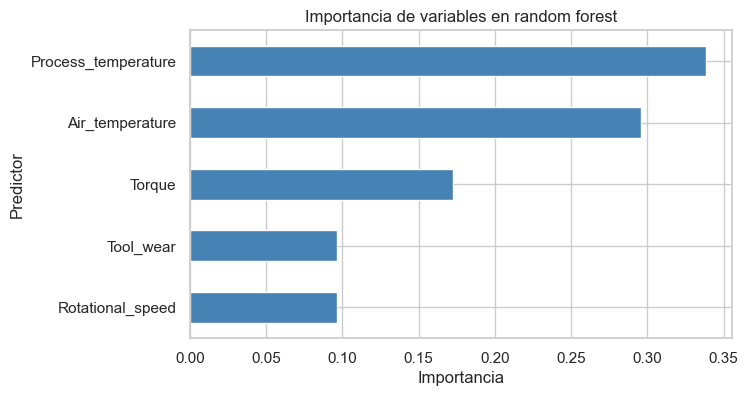

In [12]:
random_forest_model = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
)
random_forest_model.fit(X_train, Y_train)

feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X_train.columns,
).sort_values()

plt.figure(figsize=(7, 4))
feature_importance.plot(kind="barh", color="steelblue")
plt.xlabel("Importancia")
plt.ylabel("Predictor")
plt.title("Importancia de variables en random forest")
plt.show()


B) Compute the accuracy of the random forest algorithm on the test dataset.

In [13]:
# Predice sobre los datos de prueba y calcula la exactitud del random forest.
Y_pred_rf = random_forest_model.predict(X_test)
random_forest_accuracy = accuracy_score(Y_test, Y_pred_rf)

print(f"Exactitud de random forest en prueba: {random_forest_accuracy:.4f}")


Exactitud de random forest en prueba: 0.9850


## Question 6

What classification algorithm is best and why?

Respuesta

El mejor algoritmo fue random forest porque obtuvo la mayor exactitud en los datos de prueba, con un valor cercano a `0.9850`. Su desempeño fue mejor que el del árbol simple (`0.9549`) y también superior al de KNN y al árbol podado, que quedaron alrededor de `0.9624`. Esto tiene sentido porque random forest combina muchos árboles y así suele captar mejor el patrón de los datos sin depender tanto de un solo árbol.
